# Quartet multiomics: preprocessing and EDA (step 01)

Load raw Figshare matrices, apply lab/client selection to build the deterministic
four-client 72-sample federation, inspect the batch/condition structure, and
visualise the uncorrected data. Outputs are EDA figures saved to `plots/` and
pre-filtered data files saved to `filtered_data/`.

Set `DATASET_ID` to explore a single dataset interactively, or run the final
bulk-generation cell to produce plots for all datasets in `DATASET_IDS`.

**Pipeline position:** this notebook is step 01 and must be run first.
It writes `filtered_data/{Omics}_filtered.tsv` and `filtered_data/metadata_filtered.tsv`,
which are the sole inputs consumed by `02_prepare_RBE_inputs.ipynb`.

In [11]:
library(tidyverse)

In [12]:
WORKDIR      <- if (dir.exists("figshare_data")) "." else "evaluation_data/multiomics"
DATA_DIR     <- file.path(WORKDIR, "figshare_data")
PLOTS_DIR    <- file.path(WORKDIR, "plots")
FILTERED_DIR <- file.path(WORKDIR, "filtered_data")
dir.create(PLOTS_DIR,    showWarnings = FALSE, recursive = TRUE)
dir.create(FILTERED_DIR, showWarnings = FALSE, recursive = TRUE)

# filtering.R  – provides fedrbe_min_samples()
# plots_eda.R  – provides pca_plot() used for all PCA visualisation below
source(file.path(WORKDIR, "..", "..", "evaluation_utils", "filtering.R"))
source(file.path(WORKDIR, "..", "..", "evaluation_utils", "plots_eda.R"))

# DATASET_ID   – single dataset for the interactive exploration cells below.
# DATASET_IDS  – all datasets processed by the bulk plot-generation cell.
# Valid IDs: Transcriptomics_full | Proteomics_full | Metabolomics_full
DATASET_ID  <- "Transcriptomics_full"
DATASET_IDS <- c("Transcriptomics_full", "Proteomics_full", "Metabolomics_full")

# Donor levels match the Quartet figshare design; D6 is the reference (intercept).
DONOR_LEVELS    <- c("D6", "D5", "F7", "M8")
DONOR_REFERENCE <- DONOR_LEVELS[1]
COVARIATES      <- DONOR_LEVELS[-1]   # passed to fedrbe_min_samples()

## Dataset registry

Maps each `dataset_id` to its Figshare file and measurement scale.
Only the three full-dataset files (180 samples each) are used in this notebook.

In [13]:
# Only the three full datasets are used in this notebook.
# The balanced/confounded scenarios are handled in 02_prepare_RBE_inputs.ipynb.
dataset_registry <- tribble(
  ~dataset_id,             ~omics,            ~file_name,                                             ~scale,
  "Transcriptomics_full",  "Transcriptomics", "Transcriptomics_fulldataset_log2FPKM_r26907c180.csv",  "log2(FPKM + 0.01)",
  "Proteomics_full",       "Proteomics",      "Proteomics_fulldataset_log2FOT_r3489c180.csv",         "log2(FOT + 0.01)",
  "Metabolomics_full",     "Metabolomics",    "Metabolomics_fulldataset_log2expr_r71c180.csv",        "log2(expr + 1)"
)

dataset_registry

# Validate DATASET_ID and pull the single matching row for use in later cells.
selected <- dataset_registry %>% filter(dataset_id == DATASET_ID)
if (nrow(selected) != 1) stop("Unknown DATASET_ID: ", DATASET_ID, call. = FALSE)
selected

dataset_id,omics,file_name,scale
<chr>,<chr>,<chr>,<chr>
Transcriptomics_full,Transcriptomics,Transcriptomics_fulldataset_log2FPKM_r26907c180.csv,log2(FPKM + 0.01)
Proteomics_full,Proteomics,Proteomics_fulldataset_log2FOT_r3489c180.csv,log2(FOT + 0.01)
Metabolomics_full,Metabolomics,Metabolomics_fulldataset_log2expr_r71c180.csv,log2(expr + 1)


dataset_id,omics,file_name,scale
<chr>,<chr>,<chr>,<chr>
Transcriptomics_full,Transcriptomics,Transcriptomics_fulldataset_log2FPKM_r26907c180.csv,log2(FPKM + 0.01)


## Lab/client selection (fixed)

Lab IDs `L01..L15` in the figshare metadata are enumerated **independently within
each modality**, so the same `Lxx` can refer to different institutions across
modalities. Only labs that appear in all three modalities can host a real
cross-modality client. Three labs satisfy this (`L01`, `L02`, `L05`); a fourth
*optional* synthetic client folds `L03` (Metabolomics + Transcriptomics) and
`L14` (Proteomics) into `client_04_L03_L14` so every client covers all three
layers when enabled.

`SELECTED_BATCHES` lists which batch tokens each lab contributes per modality.
`CLIENT_LAB_MAPS` maps each (lab, modality) pair to its canonical client name.
Both registries always carry the full four-client layout for documentation;
the boolean toggle `INCLUDE_CLIENT_04` (default `FALSE`) controls whether the
synthetic `client_04_L03_L14` is actually built. With the default, no folder,
file or metadata row is generated for that client. Set `INCLUDE_CLIENT_04 <- TRUE`
here and at the top of `02_prepare_RBE_inputs.ipynb` /
`03_central_RBE.ipynb` to restore the full four-client federation.

In [14]:
# Toggle: include the synthetic client_04_L03_L14 (L03 + L14 fold-in).
# Default FALSE -- only the three real cross-modality clients are generated.
# Set to TRUE (and mirror in 02_prepare_RBE_inputs.ipynb / 03_central_RBE.ipynb)
# to restore the full four-client federation used in earlier runs.
INCLUDE_CLIENT_04 <- FALSE

# Optional clients pruned when INCLUDE_CLIENT_04 is FALSE. Listed once so the
# selection rationale stays in one place.
OPTIONAL_CLIENTS <- c("client_04_L03_L14")

# Full 4-client registry (always defined; pruned below when the toggle is FALSE).
ALL_SELECTED_BATCHES <- list(
  Transcriptomics = list(
    L01 = c("P_ILM_L1_B1"),
    L02 = c("P_ILM_L2_B1"),
    L05 = c("P_ILM_L5_B1", "R_ILM_L5_B2"),
    L03 = c("P_BGI_L3_B1", "R_BGI_L3_B1")
  ),
  Proteomics = list(
    L01 = c("ABS_QTOF6600_1"),
    L02 = c("APT_QE-HFX_1"),
    L05 = c("FDU_Lumos_1", "FDU_QE-HFX_4"),
    L14 = c("TMO_Exploris480_1", "TMO_QE-HFX_1")
  ),
  Metabolomics = list(
    L01 = c("U_L1_01"),
    L02 = c("U_L2_01"),
    L05 = c("U_L5_01"),
    L04 = c("T_L4_01"),
    L03 = c("U_L3_01", "U_L3_02")
  )
)

# Maps (modality, lab) → canonical client name (full 4-client layout).
ALL_CLIENT_LAB_MAPS <- list(
  Transcriptomics = c(L01 = "client_01_L01", L02 = "client_02_L02",
                      L05 = "client_03_L05_L04", L03 = "client_04_L03_L14"),
  Proteomics      = c(L01 = "client_01_L01", L02 = "client_02_L02",
                      L05 = "client_03_L05_L04", L14 = "client_04_L03_L14"),
  Metabolomics    = c(L01 = "client_01_L01", L02 = "client_02_L02",
                      L05 = "client_03_L05_L04", L04 = "client_03_L05_L04",
                      L03 = "client_04_L03_L14")
)

ALL_CLIENT_NAMES <- c("client_01_L01", "client_02_L02",
                     "client_03_L05_L04", "client_04_L03_L14")

# Active registries derived from INCLUDE_CLIENT_04. Each modality drops the
# (lab -> optional client) entries when the toggle is FALSE; the lab batches
# without a client mapping are dropped too so they never enter filtering.
active_clients <- if (INCLUDE_CLIENT_04) {
  ALL_CLIENT_NAMES
} else {
  setdiff(ALL_CLIENT_NAMES, OPTIONAL_CLIENTS)
}
CLIENT_LAB_MAPS <- lapply(ALL_CLIENT_LAB_MAPS, function(lab_map) {
  lab_map[unname(lab_map) %in% active_clients]
})
SELECTED_BATCHES <- Map(function(mod_sel, lab_map) {
  mod_sel[intersect(names(mod_sel), names(lab_map))]
}, ALL_SELECTED_BATCHES, CLIENT_LAB_MAPS)
CLIENT_NAMES <- active_clients

# Validation constants follow from how many clients are active.
# 12 libs from each 1-batch client + 24 from each 2-batch client.
N_BATCHES_PER_MODALITY <- if (INCLUDE_CLIENT_04) 6L else 4L
N_LIBS_PER_MODALITY    <- if (INCLUDE_CLIENT_04) 72L else 48L

cat("INCLUDE_CLIENT_04 =", INCLUDE_CLIENT_04, "-> active clients:",
    paste(CLIENT_NAMES, collapse = ", "), "\n")

INCLUDE_CLIENT_04 = FALSE -> active clients: client_01_L01, client_02_L02, client_03_L05_L04 


## Helper functions

Only data-loading and alignment helpers are defined here.
PCA visualisation is handled by `pca_plot()` from `evaluation_utils/plots_eda.R`
(sourced in the config cell above), which wraps `prcomp`, formats axis labels
with variance explained, and saves to disk when a path is provided.

> **Note (Proteomics):** some balanced/confounded CSVs use periods in instrument
> tokens where the metadata uses hyphens. `normalize_library_ids()` unifies both
> sides before the join.

In [15]:
# ── ID normalisation ─────────────────────────────────────────────────────────

normalize_datatype <- function(x) {
  dplyr::recode(
    as.character(x),
    "RNA"        = "Transcriptomics",
    "Protein"    = "Proteomics",
    "Metabolite" = "Metabolomics",
    .default = as.character(x)
  )
}

# Proteomics CSVs use periods where metadata uses hyphens.
normalize_library_ids <- function(x, omics) {
  x <- as.character(x)
  if (omics == "Proteomics") stringr::str_replace_all(x, stringr::fixed("."), "-") else x
}

# ── Expression matrix loading ─────────────────────────────────────────────────

load_expression_matrix <- function(path, omics) {
  raw <- suppressMessages(readr::read_csv(path, show_col_types = FALSE))
  feature_id_col <- names(raw)[1]
  feature_cols   <- feature_id_col
  feature_ids    <- as.character(raw[[feature_id_col]])

  # Metabolomics files carry a human-readable name column; combine it with the ID.
  if ("metabolite_name" %in% names(raw)) {
    feature_cols <- c(feature_cols, "metabolite_name")
    feature_ids  <- paste(feature_ids, raw[["metabolite_name"]], sep = "|")
  }

  expr <- raw %>% select(-all_of(feature_cols)) %>% as.data.frame(check.names = FALSE)
  rownames(expr) <- make.unique(feature_ids)
  colnames(expr) <- normalize_library_ids(colnames(expr), omics)
  expr[] <- lapply(expr, as.numeric)
  as.matrix(expr)
}

# ── Metadata loading ──────────────────────────────────────────────────────────

# Reads the shared 180-sample metadata CSV and normalises data-type labels.
# Returns all modalities; filtering to a single modality happens downstream.
load_full_metadata <- function(path) {
  readr::read_csv(path, show_col_types = FALSE) %>%
    mutate(datatype = normalize_datatype(datatype)) %>%
    transmute(
      file       = library,
      condition  = sample,
      batch      = batch,
      lab        = lab,
      platform   = platform,
      protocol   = replace_na(as.character(protocol), "not_available"),
      datatype   = datatype,
      rep        = as.integer(rep),
      date       = as.character(date)
    )
}

# ── Lab/client selection filtering ───────────────────────────────────────────

# Keeps only the (lab, batch) pairs listed in SELECTED_BATCHES[[modality]].
filter_to_selected_batches <- function(metadata, modality) {
  selection <- SELECTED_BATCHES[[modality]]
  if (is.null(selection)) stop(modality, ": no SELECTED_BATCHES entry.", call. = FALSE)
  keep_pairs <- bind_rows(lapply(names(selection), function(lab) {
    tibble(lab = lab, batch = selection[[lab]])
  }))
  filtered <- metadata %>% semi_join(keep_pairs, by = c("lab", "batch"))
  expected_n <- sum(purrr::map_int(selection, length)) * 12L   # 12 libs per batch
  if (nrow(filtered) != expected_n) {
    stop(modality, ": expected ", expected_n, " libraries after filtering, got ",
         nrow(filtered), call. = FALSE)
  }
  filtered
}

# Assigns each library to its canonical client, derives batch_code and pseudo_sample.
assign_client_and_keys <- function(metadata, modality) {
  lab_map  <- CLIENT_LAB_MAPS[[modality]]
  if (is.null(lab_map)) stop(modality, ": no CLIENT_LAB_MAPS entry.", call. = FALSE)
  unmapped <- setdiff(unique(metadata$lab), names(lab_map))
  if (length(unmapped) > 0)
    stop(modality, ": unmapped labs: ", paste(unmapped, collapse = ", "), call. = FALSE)

  metadata <- metadata %>%
    mutate(
      client     = unname(lab_map[as.character(lab)]),
      client     = factor(client, levels = CLIENT_NAMES),
      batch_code = sprintf("B%02d", dense_rank(batch))
    ) %>%
    arrange(client, condition, rep, batch) %>%
    group_by(client, condition, rep) %>%
    mutate(within_cell_idx = row_number()) %>%
    ungroup() %>%
    mutate(
      pseudo_sample = sprintf("%s_%s_%d_%d",
                              as.character(client), as.character(condition),
                              rep, within_cell_idx)
    ) %>%
    select(-within_cell_idx) %>%
    mutate(client = as.character(client))

  if (anyDuplicated(metadata$pseudo_sample) > 0)
    stop(modality, ": duplicate pseudo_sample keys.", call. = FALSE)
  metadata
}

# Validates that the filtered design has the expected number of samples, batches,
# donor levels, per-donor counts, replicates per batch, and canonical clients.
# This matches the stricter validation used by 02_prepare_RBE_inputs.ipynb.
validate_filtered_design <- function(metadata, label) {
  if (nrow(metadata) != N_LIBS_PER_MODALITY)
    stop(label, ": expected ", N_LIBS_PER_MODALITY, " samples, got ", nrow(metadata), call. = FALSE)
  if (n_distinct(metadata$batch) != N_BATCHES_PER_MODALITY)
    stop(label, ": expected ", N_BATCHES_PER_MODALITY, " batches.", call. = FALSE)
  if (!setequal(as.character(unique(metadata$condition)), DONOR_LEVELS))
    stop(label, ": unexpected condition levels: ", paste(unique(metadata$condition), collapse = ", "), call. = FALSE)
  donor_counts       <- metadata %>% count(condition)
  expected_per_donor <- N_LIBS_PER_MODALITY %/% length(DONOR_LEVELS)
  if (any(donor_counts$n != expected_per_donor))
    stop(label, ": expected ", expected_per_donor, " samples per donor.", call. = FALSE)
  batch_donor_counts <- metadata %>% count(batch, condition)
  bad            <- batch_donor_counts %>% filter(n != 3)
  expected_cells <- N_BATCHES_PER_MODALITY * length(DONOR_LEVELS)
  if (nrow(bad) > 0 || nrow(batch_donor_counts) != expected_cells)
    stop(label, ": expected exactly 3 replicates per donor in every batch.", call. = FALSE)
  client_counts <- metadata %>% count(client)
  if (!setequal(client_counts$client, CLIENT_NAMES))
    stop(label, ": expected exactly the active canonical clients (",
         paste(CLIENT_NAMES, collapse = ", "), ").", call. = FALSE)
  if (any(!client_counts$n %in% c(12L, 24L)))
    stop(label, ": each client must have 12 or 24 libraries.", call. = FALSE)
  invisible(metadata)
}

# ── Sample alignment ──────────────────────────────────────────────────────────

# Aligns expression columns to metadata rows, sorted by (client, batch, condition, rep)
# for a deterministic output order. Errors if metadata samples are missing from the
# matrix; extra matrix columns are silently ignored (expected when loading the full
# 180-sample Figshare file while metadata has been filtered to 72 samples).
align_expression_to_metadata <- function(expr, metadata) {
  missing_in_matrix <- setdiff(metadata$file, colnames(expr))
  if (length(missing_in_matrix) > 0)
    stop("Metadata samples missing from expression matrix: ",
         paste(head(missing_in_matrix, 10), collapse = ", "), call. = FALSE)
  metadata <- metadata %>% arrange(client, batch, condition, rep)
  expr     <- expr[, metadata$file, drop = FALSE]
  list(expr = expr, metadata = metadata)
}

## Load, filter, and align selected dataset

Load the full expression matrix for `DATASET_ID` and the 180-sample metadata,
apply lab/client selection to restrict to the 72-sample four-client federation,
validate the filtered design, and align matrix columns to metadata rows.

In [16]:
# Load the full expression matrix and 180-sample metadata, apply lab/client
# selection to restrict to the 72-sample four-client federation, validate the
# design, then align expression columns to the metadata row order.
expr      <- load_expression_matrix(file.path(DATA_DIR, selected$file_name), selected$omics)
full_meta <- load_full_metadata(file.path(DATA_DIR, "meta_full_dataset_3omics.csv"))
metadata  <- full_meta %>%
  filter(datatype == selected$omics) %>%
  mutate(
    file      = normalize_library_ids(file, selected$omics),
    condition = factor(condition, levels = DONOR_LEVELS)
  ) %>%
  filter_to_selected_batches(selected$omics) %>%
  mutate(condition = as.character(condition)) %>%
  assign_client_and_keys(selected$omics)
validate_filtered_design(metadata, selected$omics)

aligned  <- align_expression_to_metadata(expr, metadata)
expr     <- aligned$expr
metadata <- aligned$metadata

# Quick sanity check: dimensions and a glimpse of all metadata columns.
cat("Dataset:", DATASET_ID, "\n")
cat("Omics:  ", selected$omics, "\n")
cat("Scale:  ", selected$scale, "\n")
cat("Matrix: ", nrow(expr), "features ×", ncol(expr), "samples\n")
cat("Metadata:", nrow(metadata), "rows ×", ncol(metadata), "columns\n")

metadata %>% glimpse()

Dataset: Transcriptomics_full 
Omics:   Transcriptomics 
Scale:   log2(FPKM + 0.01) 
Matrix:  26907 features × 48 samples
Metadata: 48 rows × 12 columns
Rows: 48
Columns: 12
$ file          <chr> "P_ILM_L1_B1_D5_1", "P_ILM_L1_B1_D5_2", "P_ILM_L1_B1_D5_…
$ condition     <chr> "D5", "D5", "D5", "D6", "D6", "D6", "F7", "F7", "F7", "M…
$ batch         <chr> "P_ILM_L1_B1", "P_ILM_L1_B1", "P_ILM_L1_B1", "P_ILM_L1_B…
$ lab           <chr> "L01", "L01", "L01", "L01", "L01", "L01", "L01", "L01", …
$ platform      <chr> "ILM", "ILM", "ILM", "ILM", "ILM", "ILM", "ILM", "ILM", …
$ protocol      <chr> "P", "P", "P", "P", "P", "P", "P", "P", "P", "P", "P", "…
$ datatype      <chr> "Transcriptomics", "Transcriptomics", "Transcriptomics",…
$ rep           <int> 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1,…
$ date          <chr> "20200602", "20200602", "20200602", "20200602", "2020060…
$ client        <chr> "client_01_L01", "client_01_L01", "client_01_L01", "clie…
$ batch_code    <chr> "B01

## Metadata and batch structure

Tabulate samples by condition, batch, lab, and platform to verify the experimental
design. Also compute the FedRBE privacy-floor threshold (`fedrbe_min_samples`)
for this batch/covariate combination.

In [17]:
# Cross-tabulate conditions, batches, clients, and platforms.
metadata %>% count(condition, name = "n_samples")
metadata %>% count(batch_code, batch, condition) %>%
  pivot_wider(names_from = condition, values_from = n, values_fill = 0)
metadata %>% count(client, batch_code, name = "n_samples") %>%
  arrange(client, batch_code)
metadata %>% count(lab, platform, batch, name = "n_samples") %>%
  arrange(lab, platform, batch)

# FedRBE privacy floor: minimum samples per batch given the number of batches
# and biological covariates (DONOR_REFERENCE = D6 is the intercept, excluded).
fedrbe_effective_min_samples <- fedrbe_min_samples(
  num_batches = n_distinct(metadata$batch),
  covariates  = COVARIATES,
  min_samples = 0
)
cat("Batches:  ", n_distinct(metadata$batch),   "\n")
cat("Clients:  ", n_distinct(metadata$client),  "\n")
cat("Labs:     ", n_distinct(metadata$lab),     "\n")
cat("Platforms:", n_distinct(metadata$platform), "\n")
cat(
  "FedRBE minimum samples for", n_distinct(metadata$batch),
  "batches and donor covariates:", fedrbe_effective_min_samples, "\n"
)

condition,n_samples
<chr>,<int>
D5,12
D6,12
F7,12
M8,12


batch_code,batch,D5,D6,F7,M8
<chr>,<chr>,<int>,<int>,<int>,<int>
B01,P_ILM_L1_B1,3,3,3,3
B02,P_ILM_L2_B1,3,3,3,3
B03,P_ILM_L5_B1,3,3,3,3
B04,R_ILM_L5_B2,3,3,3,3


client,batch_code,n_samples
<chr>,<chr>,<int>
client_01_L01,B01,12
client_02_L02,B02,12
client_03_L05_L04,B03,12
client_03_L05_L04,B04,12


lab,platform,batch,n_samples
<chr>,<chr>,<chr>,<int>
L01,ILM,P_ILM_L1_B1,12
L02,ILM,P_ILM_L2_B1,12
L05,ILM,P_ILM_L5_B1,12
L05,ILM,R_ILM_L5_B2,12


Batches:   4 
Clients:   3 
Labs:      3 
Platforms: 1 
FedRBE minimum samples for 4 batches and donor covariates: 8 


## Expression summaries

Per-sample statistics (median, IQR, missing-value fraction) and per-feature
statistics (variance, missingness). Useful to catch outlier samples or features
with extreme missingness before batch correction.

In [18]:
# Per-sample statistics joined to metadata for grouping in downstream plots.
sample_stats <- tibble(
  file             = colnames(expr),
  missing_values   = colSums(is.na(expr)),
  missing_fraction = colMeans(is.na(expr)),
  median           = apply(expr, 2, median, na.rm = TRUE),
  mean             = colMeans(expr, na.rm = TRUE),
  iqr              = apply(expr, 2, IQR,    na.rm = TRUE)
) %>% left_join(metadata, by = "file")

# Per-feature statistics: flag features with high missingness or zero/non-finite variance
# (such features will be dropped by prepare_pca and may need filtering before correction).
feature_stats <- tibble(
  feature          = rownames(expr),
  missing_fraction = rowMeans(is.na(expr)),
  variance         = apply(expr, 1, var, na.rm = TRUE)
)

sample_stats %>% summary()

feature_stats %>% summarize(
  n_features              = n(),
  n_complete              = sum(missing_fraction == 0),
  median_missing_fraction = median(missing_fraction),
  max_missing_fraction    = max(missing_fraction),
  n_zero_or_na_variance   = sum(!is.finite(variance) | variance == 0)
)

     file           missing_values missing_fraction     median        
 Length:48          Min.   :0      Min.   :0        Min.   :-0.76800  
 Class :character   1st Qu.:0      1st Qu.:0        1st Qu.:-0.47925  
 Mode  :character   Median :0      Median :0        Median :-0.28900  
                    Mean   :0      Mean   :0        Mean   :-0.20913  
                    3rd Qu.:0      3rd Qu.:0        3rd Qu.:-0.03525  
                    Max.   :0      Max.   :0        Max.   : 0.55400  
      mean              iqr         condition            batch          
 Min.   :-1.0097   Min.   :3.608   Length:48          Length:48         
 1st Qu.:-0.6318   1st Qu.:4.563   Class :character   Class :character  
 Median :-0.4758   Median :5.041   Mode  :character   Mode  :character  
 Mean   :-0.3667   Mean   :4.938                                        
 3rd Qu.:-0.1115   3rd Qu.:5.452                                        
 Max.   : 0.3448   Max.   :8.930                                 

n_features,n_complete,median_missing_fraction,max_missing_fraction,n_zero_or_na_variance
<int>,<int>,<dbl>,<dbl>,<int>
26907,26907,0,0,0


## PCA before correction (filtered 4-client data)

Uses `pca_plot()` from `evaluation_utils/plots_eda.R` on the filtered 72-sample
four-client subset. Features with any NA are dropped via `na.omit` before
`prcomp`. Axes show variance explained.

Three views are produced: coloured by **batch**, **client**, and **condition**.
A strong PC1/PC2 split by batch or client indicates a technical effect that
warrants correction.

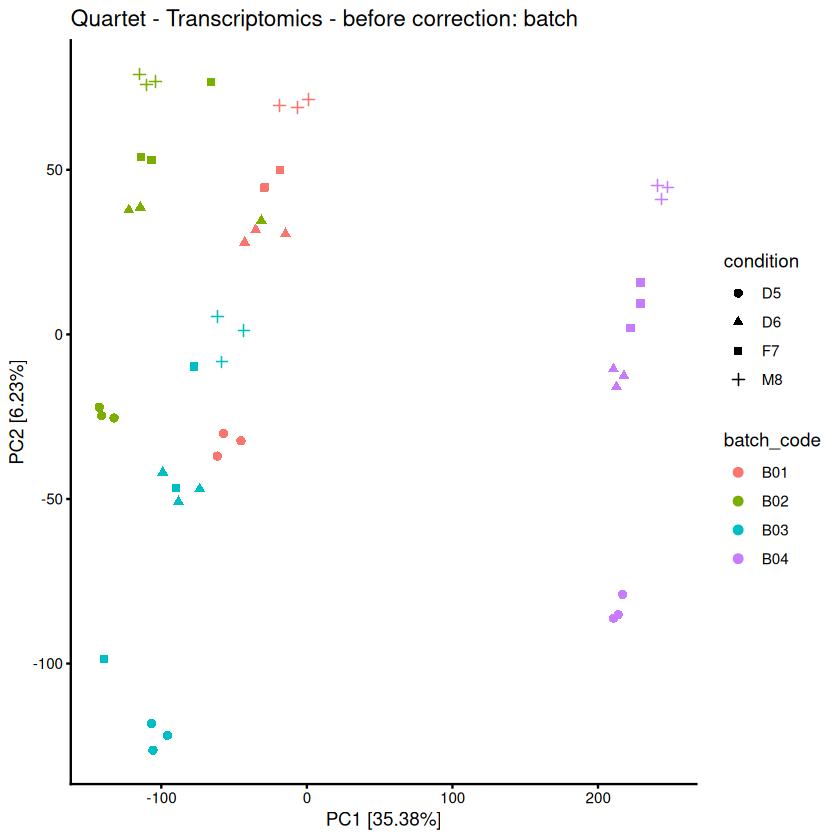

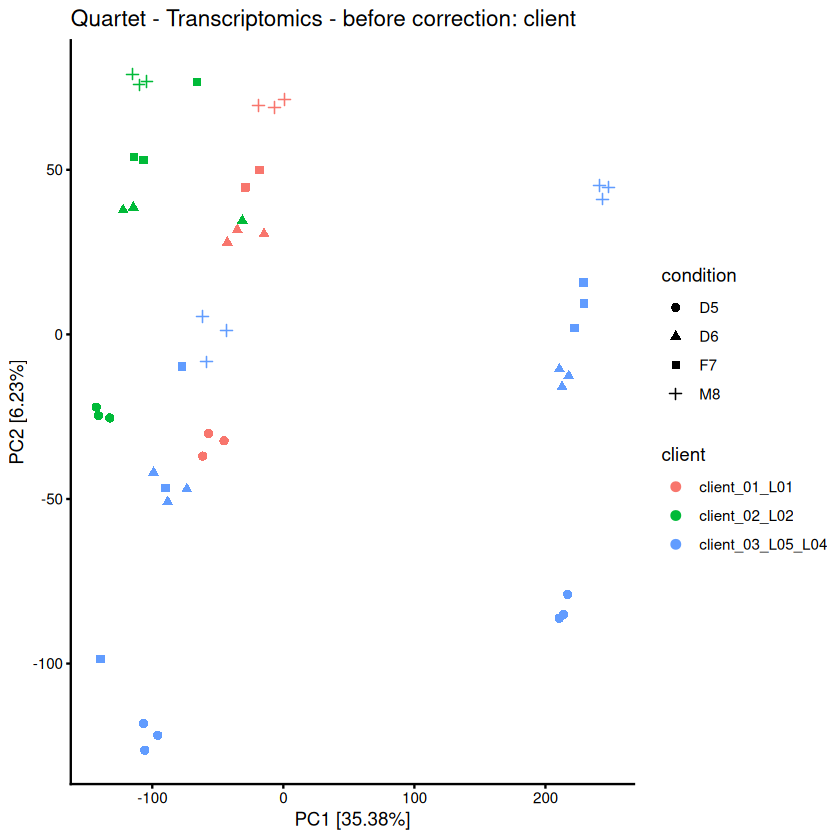

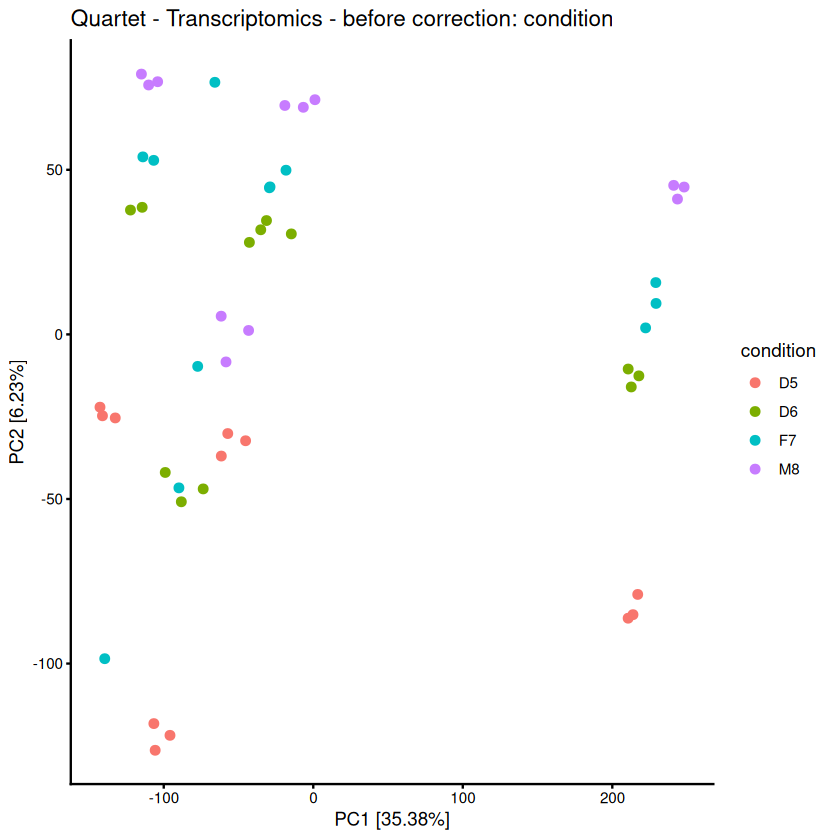

In [19]:
# pca_plot() from plots_eda.R: runs prcomp on na.omit(expr), joins metadata by
# quantitative_col_name, colours/shapes points by the specified columns, and
# saves to path if non-empty.
plot_title <- paste0("Quartet - ", selected$omics)

p_batch <- pca_plot(
  df                    = expr,
  batch_info            = metadata,
  title                 = paste(plot_title, "- before correction: batch"),
  quantitative_col_name = "file",
  col_col               = "batch_code",
  shape_col             = "condition",
  path                  = file.path(PLOTS_DIR, paste0(DATASET_ID, "_pca_by_batch.png"))
)

p_client <- pca_plot(
  df                    = expr,
  batch_info            = metadata,
  title                 = paste(plot_title, "- before correction: client"),
  quantitative_col_name = "file",
  col_col               = "client",
  shape_col             = "condition",
  path                  = file.path(PLOTS_DIR, paste0(DATASET_ID, "_pca_by_client.png"))
)

p_condition <- pca_plot(
  df                    = expr,
  batch_info            = metadata,
  title                 = paste(plot_title, "- before correction: condition"),
  quantitative_col_name = "file",
  col_col               = "condition",
  path                  = file.path(PLOTS_DIR, paste0(DATASET_ID, "_pca_by_condition.png"))
)

p_batch
p_client
p_condition

## Boxplots before correction (filtered 4-client data)

Uses `boxplot_plot()` from `evaluation_utils/plots_eda.R` (per-sample boxplots,
x = sample, fill = group). Two panels stacked vertically: coloured by **batch**
and by **condition**. Combined figure saved to `plots/`.

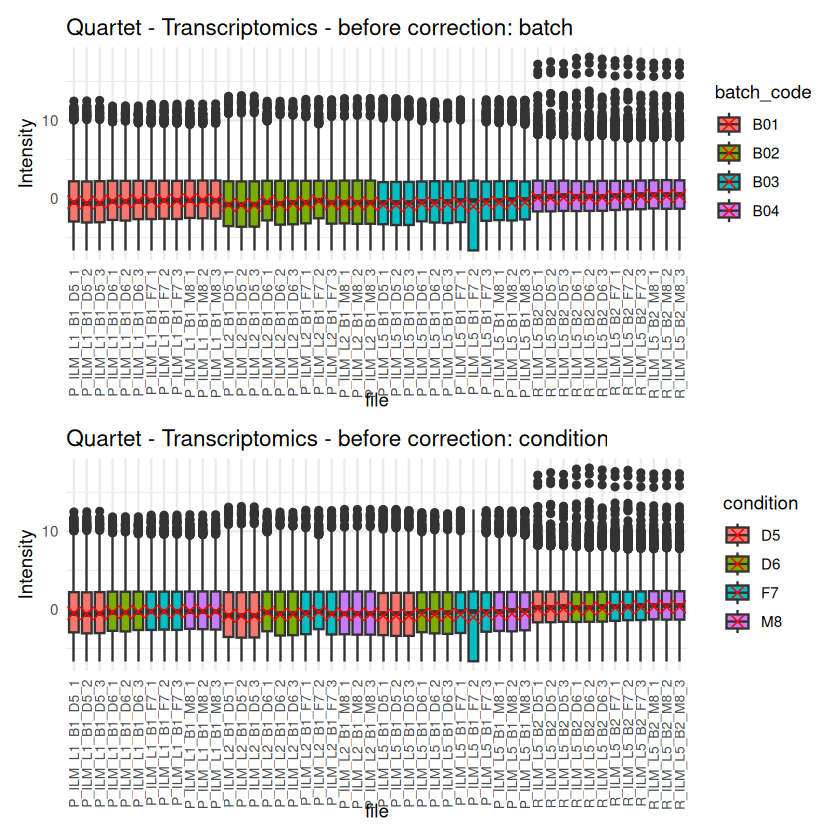

In [20]:
# boxplot_plot() from plots_eda.R: per-sample boxplots (x = sample, fill = group).
# path="" returns the plot object without saving; combine with patchwork then ggsave.
plot_title <- paste0("Quartet - ", selected$omics)

p_batch <- boxplot_plot(
  expr, metadata,
  quantitativeColumnName = "file",
  color_col              = "batch_code",
  title                  = paste(plot_title, "- before correction: batch")
)

p_condition <- boxplot_plot(
  expr, metadata,
  quantitativeColumnName = "file",
  color_col              = "condition",
  title                  = paste(plot_title, "- before correction: condition")
)

combined <- p_batch / p_condition
ggsave(
  file.path(PLOTS_DIR, paste0(DATASET_ID, "_boxplot_batch_condition.png")),
  combined, width = 14, height = 10
)
combined

## Bulk PCA plot generation for all multiomics datasets

Iterate over `DATASET_IDS`, apply lab/client selection for each modality, and
save PCA plots coloured by batch, client, and condition. Check `plots/` for the
saved PNGs.

In [21]:
# Save PCA plots for a single dataset_id using pca_plot() from plots_eda.R.
# Applies lab/client selection (72-sample four-client subset) before plotting.
# Returns a one-row tibble with dataset dimensions for the progress summary.
save_dataset_pca_plots <- function(dataset_id) {
  sel <- dataset_registry %>% filter(.data$dataset_id == .env$dataset_id)
  if (nrow(sel) != 1) stop("Unknown DATASET_ID: ", dataset_id, call. = FALSE)

  expr_i    <- load_expression_matrix(file.path(DATA_DIR, sel$file_name), sel$omics)
  full_meta <- load_full_metadata(file.path(DATA_DIR, "meta_full_dataset_3omics.csv"))
  meta_i    <- full_meta %>%
    filter(datatype == sel$omics) %>%
    mutate(
      file      = normalize_library_ids(file, sel$omics),
      condition = factor(condition, levels = DONOR_LEVELS)
    ) %>%
    filter_to_selected_batches(sel$omics) %>%
    mutate(condition = as.character(condition)) %>%
    assign_client_and_keys(sel$omics)
  validate_filtered_design(meta_i, sel$omics)

  aligned_i  <- align_expression_to_metadata(expr_i, meta_i)
  expr_i     <- aligned_i$expr
  meta_i     <- aligned_i$metadata
  plot_title <- paste0("Quartet - ", sel$omics)

  pca_plot(
    df = expr_i, batch_info = meta_i,
    title = paste(plot_title, "- before correction: batch"),
    quantitative_col_name = "file", col_col = "batch_code", shape_col = "condition",
    path = file.path(PLOTS_DIR, paste0(dataset_id, "_pca_by_batch.png"))
  )
  pca_plot(
    df = expr_i, batch_info = meta_i,
    title = paste(plot_title, "- before correction: client"),
    quantitative_col_name = "file", col_col = "client", shape_col = "condition",
    path = file.path(PLOTS_DIR, paste0(dataset_id, "_pca_by_client.png"))
  )
  pca_plot(
    df = expr_i, batch_info = meta_i,
    title = paste(plot_title, "- before correction: condition"),
    quantitative_col_name = "file", col_col = "condition",
    path = file.path(PLOTS_DIR, paste0(dataset_id, "_pca_by_condition.png"))
  )

  tibble(
    dataset_id = dataset_id,
    omics      = sel$omics,
    features   = nrow(expr_i),
    samples    = ncol(expr_i),
    batches    = n_distinct(meta_i$batch),
    clients    = n_distinct(meta_i$client)
  )
}

# Run over all DATASET_IDS and print a compact summary table.
plot_summaries <- purrr::map_dfr(DATASET_IDS, save_dataset_pca_plots)
plot_summaries

dataset_id,omics,features,samples,batches,clients
<chr>,<chr>,<int>,<int>,<int>,<int>
Transcriptomics_full,Transcriptomics,26907,48,4,3
Proteomics_full,Proteomics,3489,48,4,3
Metabolomics_full,Metabolomics,71,48,4,3


## Bulk boxplot generation for all multiomics datasets

Iterate over `DATASET_IDS`, build per-sample boxplots coloured by **batch** and
**condition** via `boxplot_plot()` from `plots_eda.R`, combine into a single
2-panel figure, and save to `plots/`.

In [22]:
# Mirrors save_dataset_pca_plots(): load + filter + align, then build two
# boxplots (batch / condition), combine with patchwork, and save.
save_dataset_boxplots <- function(dataset_id) {
  sel <- dataset_registry %>% filter(.data$dataset_id == .env$dataset_id)
  if (nrow(sel) != 1) stop("Unknown DATASET_ID: ", dataset_id, call. = FALSE)

  expr_i    <- load_expression_matrix(file.path(DATA_DIR, sel$file_name), sel$omics)
  full_meta <- load_full_metadata(file.path(DATA_DIR, "meta_full_dataset_3omics.csv"))
  meta_i    <- full_meta %>%
    filter(datatype == sel$omics) %>%
    mutate(
      file      = normalize_library_ids(file, sel$omics),
      condition = factor(condition, levels = DONOR_LEVELS)
    ) %>%
    filter_to_selected_batches(sel$omics) %>%
    mutate(condition = as.character(condition)) %>%
    assign_client_and_keys(sel$omics)
  validate_filtered_design(meta_i, sel$omics)

  aligned_i  <- align_expression_to_metadata(expr_i, meta_i)
  expr_i     <- aligned_i$expr
  meta_i     <- aligned_i$metadata
  plot_title <- paste0("Quartet - ", sel$omics)

  p_batch <- boxplot_plot(
    expr_i, meta_i,
    quantitativeColumnName = "file", color_col = "batch_code",
    title = paste(plot_title, "- before correction: batch")
  )
  p_condition <- boxplot_plot(
    expr_i, meta_i,
    quantitativeColumnName = "file", color_col = "condition",
    title = paste(plot_title, "- before correction: condition")
  )

  combined <- p_batch / p_condition
  ggsave(
    file.path(PLOTS_DIR, paste0(dataset_id, "_boxplot_batch_condition.png")),
    combined, width = 14, height = 10
  )
  invisible(dataset_id)
}

purrr::walk(DATASET_IDS, save_dataset_boxplots)
cat("Boxplots saved to", PLOTS_DIR, "\n")

Boxplots saved to ./plots 


## Save filtered data

Write the filtered 72-sample expression matrices and the combined metadata to
`filtered_data/`. These files are the sole handoff artefact consumed by
`02_prepare_RBE_inputs.ipynb`, which reads them directly instead of
re-running lab/client selection.

In [23]:
# Save filtered expression matrices and combined metadata to filtered_data/.
# 02_prepare_RBE_inputs.ipynb reads these files instead of re-doing filtering.
FILTERED_DIR <- file.path(WORKDIR, "filtered_data")
dir.create(FILTERED_DIR, showWarnings = FALSE, recursive = TRUE)

full_meta_save <- load_full_metadata(
  file.path(DATA_DIR, "meta_full_dataset_3omics.csv")
)

all_metadata_filtered <- purrr::map_dfr(seq_len(nrow(dataset_registry)), function(i) {
  sel <- dataset_registry[i, ]

  # Load full 180-sample expression matrix and apply lab/client selection.
  expr_i <- load_expression_matrix(file.path(DATA_DIR, sel$file_name), sel$omics)
  meta_i <- full_meta_save %>%
    filter(datatype == sel$omics) %>%
    mutate(
      file      = normalize_library_ids(file, sel$omics),
      condition = factor(condition, levels = DONOR_LEVELS)
    ) %>%
    filter_to_selected_batches(sel$omics) %>%
    mutate(condition = as.character(condition)) %>%
    assign_client_and_keys(sel$omics)
  validate_filtered_design(meta_i, sel$omics)

  aligned_i <- align_expression_to_metadata(expr_i, meta_i)
  expr_i    <- aligned_i$expr
  meta_i    <- aligned_i$metadata

  # Write expression matrix (feature_id column + 72 sample columns) as TSV.
  out <- as.data.frame(expr_i, check.names = FALSE) %>%
    tibble::rownames_to_column("feature_id")
  out_path <- file.path(FILTERED_DIR, paste0(sel$omics, "_filtered.tsv"))
  write.table(out, file = out_path,
              sep = "\t", quote = TRUE, row.names = FALSE, col.names = TRUE)
  cat(sel$omics, ":", nrow(expr_i), "features x", ncol(expr_i), "samples ->", out_path, "\n")
  meta_i
})

# Write combined metadata for all three modalities in one file.
meta_out <- file.path(FILTERED_DIR, "metadata_filtered.tsv")
write.table(all_metadata_filtered, file = meta_out,
            sep = "\t", quote = TRUE, row.names = FALSE, col.names = TRUE)
cat("Metadata (all modalities):", nrow(all_metadata_filtered), "rows ->", meta_out, "\n")

Transcriptomics : 26907 features x 48 samples -> ./filtered_data/Transcriptomics_filtered.tsv 
Proteomics : 3489 features x 48 samples -> ./filtered_data/Proteomics_filtered.tsv 
Metabolomics : 71 features x 48 samples -> ./filtered_data/Metabolomics_filtered.tsv 
Metadata (all modalities): 144 rows -> ./filtered_data/metadata_filtered.tsv 


In [24]:
# Record R and package versions for reproducibility.
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 24.04.4 LTS

Matrix products: default
BLAS/LAPACK: /home/yuliya-cosybio/miniforge3/envs/fedRBE/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Berlin
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] viridis_0.6.5       viridisLite_0.4.3   ggsci_4.2.0        
 [4] umap_0.2.10.0       patchwork_1.3.2     gridExtra_2.3      
 [7] data.table_1.18.2.1 lubridate_1.9.5     forcats_1.0.1      
[10] stringr_1.6